In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df=pd.read_csv("../data/AllCombined_MentalEffortFocus.csv")
df.head()

,Person,ACCx,ACCy,ACCz,Movement,EDAz,TEMPz,HRz,Puzzle,DifficultyLevel,Correct,FocusLevel,Focus01,Age,Education,Gender,Ethnicity
0,JG,-15,31,53,63.206012,0.313571,-3.168892,-2.388134,1,0,1,0,0,18,high school,female,white
1,JG,-15,31,54,64.046858,0.257820,-3.276435,-2.342548,1,0,1,0,0,18,high school,female,white
2,JG,-14,31,54,63.820060,0.369322,-3.061348,-2.296961,1,0,1,0,0,18,high school,female,white
3,JG,-15,29,54,63.103090,0.369322,-3.061348,-0.997748,1,0,1,0,0,18,high school,female,white
4,JG,-15,29,55,63.960926,0.425073,-2.953804,-1.202887,1,0,1,0,0,18,high school,female,white


In [42]:
df.shape

(5094, 17)

In [43]:
df.columns

Index(['Person', 'ACCx', 'ACCy', 'ACCz', 'Movement', 'EDAz', 'TEMPz', 'HRz',
       'Puzzle', 'DifficultyLevel', 'Correct', 'FocusLevel', 'Focus01', 'Age',
       'Education', 'Gender', 'Ethnicity'],
      dtype='str')

In [44]:
df.dtypes

Person                 str
ACCx                 int64
ACCy                 int64
ACCz                 int64
Movement           float64
EDAz               float64
TEMPz              float64
HRz                float64
Puzzle               int64
DifficultyLevel      int64
Correct              int64
FocusLevel           int64
Focus01              int64
Age                  int64
Education              str
Gender                 str
Ethnicity              str
dtype: object

In [45]:
print(df["Correct"].value_counts())

Correct
1    2705
0    2389
Name: count, dtype: int64


In [46]:
print(df["DifficultyLevel"].value_counts())

DifficultyLevel
4    1978
3    1608
0     976
1     532
Name: count, dtype: int64


In [47]:
print(df["FocusLevel"].value_counts())

FocusLevel
2    3795
1    1239
0      60
Name: count, dtype: int64


In [48]:
print("unique persons: ",df["Person"].nunique())

unique persons:  8


In [49]:
print("unique puzzle: ",df["Puzzle"].nunique())

unique puzzle:  5


In [50]:
print(df["Person"].value_counts())

Person
MB     997
ZP     891
JMG    855
JG     574
WR     543
SG     475
RH2    391
RH1    368
Name: count, dtype: int64


In [51]:
physio_features=["EDAz","TEMPz","HRz","Movement","DifficultyLevel"]
with_focus_features=["EDAz","TEMPz","HRz","Movement","DifficultyLevel","FocusLevel"]
target="Correct"

In [52]:
print(physio_features)
print(with_focus_features)

['EDAz', 'TEMPz', 'HRz', 'Movement', 'DifficultyLevel']
['EDAz', 'TEMPz', 'HRz', 'Movement', 'DifficultyLevel', 'FocusLevel']


In [53]:
persons=df["Person"].unique().tolist()
for person in persons:
    train_df=df[df["Person"]!=person]
    test_df=df[df["Person"]==person]
    x_train=train_df[physio_features]
    y_train=train_df[target]
    x_test=test_df[physio_features]
    y_test=test_df[target]
    print(f"\nTest Person: {person}")
    print(x_train.shape, y_train.shape)
    print(x_test.shape, y_test.shape)



Test Person: JG
(4520, 5) (4520,)
(574, 5) (574,)

Test Person: JMG
(4239, 5) (4239,)
(855, 5) (855,)

Test Person: MB
(4097, 5) (4097,)
(997, 5) (997,)

Test Person: RH1
(4726, 5) (4726,)
(368, 5) (368,)

Test Person: RH2
(4703, 5) (4703,)
(391, 5) (391,)

Test Person: SG
(4619, 5) (4619,)
(475, 5) (475,)

Test Person: WR
(4551, 5) (4551,)
(543, 5) (543,)

Test Person: ZP
(4203, 5) (4203,)
(891, 5) (891,)


In [54]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models={
    "Majority Baseline":DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":LogisticRegression(C=1000,max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(max_depth=4,min_samples_split=5),
    "KNN":KNeighborsClassifier(n_neighbors=3),
    "Random Forest":RandomForestClassifier(n_estimators=100,min_samples_split=5)
}

In [55]:
results = {

    name: {

        "y_true": [],

        "y_pred": [],

        "y_prob": []

    }

    for name in models

}

persons = df["Person"].unique().tolist()

for person in persons:

    train_df = df[df["Person"] != person]
    test_df = df[df["Person"] == person]

    X_train = train_df[physio_features]
    y_train = train_df[target]

    X_test = test_df[physio_features]
    y_test = test_df[target]

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results[model_name]["y_true"].extend(y_test)
        results[model_name]["y_pred"].extend(y_pred)
        results[model_name]["y_prob"].extend(y_prob)

# Verification
for model_name in models:
    print(
        f"{model_name}:",
        len(results[model_name]["y_true"]),
        len(results[model_name]["y_pred"])
    )

Majority Baseline: 5094 5094
Logistic Regression: 5094 5094
Decision Tree: 5094 5094
KNN: 5094 5094
Random Forest: 5094 5094


In [57]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

def run_lopo(features):

    results = {
        name: {
            "y_true": [],
            "y_pred": [],
            "y_prob": []
        }
        for name in models
    }

    persons = df["Person"].unique().tolist()

    for person in persons:

        train_df = df[df["Person"] != person]
        test_df = df[df["Person"] == person]

        X_train = train_df[features]
        y_train = train_df[target]

        X_test = test_df[features]
        y_test = test_df[target]

        for model_name, model in models.items():

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            results[model_name]["y_true"].extend(y_test)
            results[model_name]["y_pred"].extend(y_pred)
            results[model_name]["y_prob"].extend(y_prob)

    return results

results_physio = run_lopo(physio_features)
results_focus = run_lopo(with_focus_features)

def print_metrics(results, title):

    print(f"\n{title}")

    print(
        f"{'Model':<20}"
        f"{'F1':<10}"
        f"{'Precision':<10}"
        f"{'Recall':<10}"
        f"{'AUC':<10}"
    )

    print("-" * 60)

    for model_name, data in results.items():

        y_true = data["y_true"]
        y_pred = data["y_pred"]
        y_prob = data["y_prob"]

        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)

        try:
            auc = roc_auc_score(y_true, y_prob)
            auc_str = f"{auc:.4f}"
        except:
            auc_str = "N/A"

        print(
            f"{model_name:<20}"
            f"{f1:<10.4f}"
            f"{precision:<10.4f}"
            f"{recall:<10.4f}"
            f"{auc_str:<10}"
        )

print_metrics(results_physio, "PHYSIO FEATURES ONLY")
print_metrics(results_focus, "PHYSIO + FOCUS FEATURES")


PHYSIO FEATURES ONLY
Model               F1        Precision Recall    AUC       
------------------------------------------------------------
Majority Baseline   0.6159    0.4923    0.8226    0.4309    
Logistic Regression 0.6225    0.6556    0.5926    0.6472    
Decision Tree       0.6608    0.7139    0.6152    0.6468    
KNN                 0.5997    0.6138    0.5863    0.6015    
Random Forest       0.6169    0.6103    0.6237    0.6395    

PHYSIO + FOCUS FEATURES
Model               F1        Precision Recall    AUC       
------------------------------------------------------------
Majority Baseline   0.6159    0.4923    0.8226    0.4309    
Logistic Regression 0.5855    0.5937    0.5774    0.6654    
Decision Tree       0.5951    0.5939    0.5963    0.6484    
KNN                 0.5504    0.5349    0.5667    0.5130    
Random Forest       0.5475    0.5176    0.5811    0.5345    


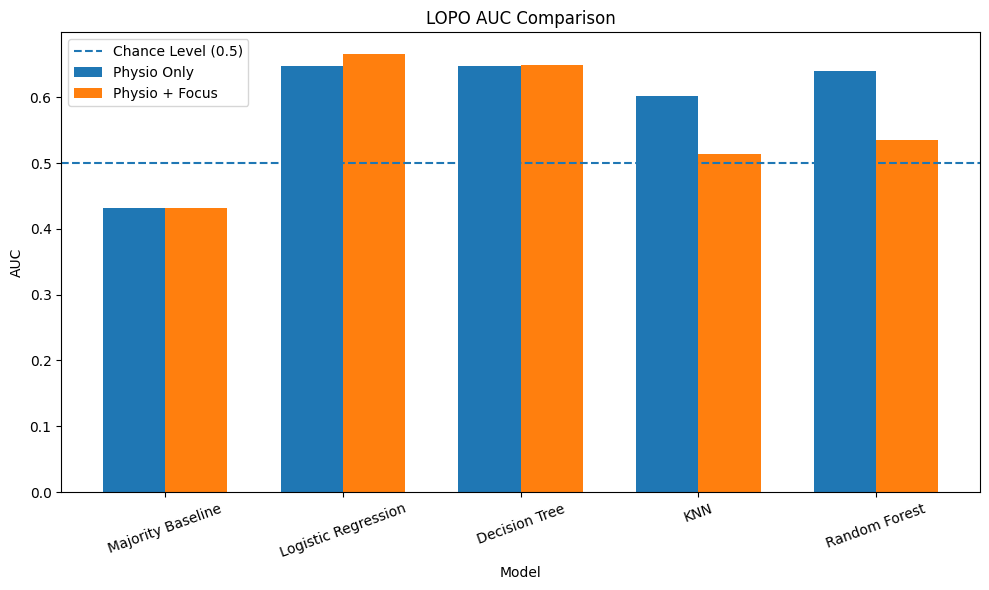

In [59]:
import numpy as np
import matplotlib.pyplot as plt

auc_physio = {}
auc_focus = {}

for model_name in models:

    auc_physio[model_name] = roc_auc_score(
        results_physio[model_name]["y_true"],
        results_physio[model_name]["y_prob"]
    )

    auc_focus[model_name] = roc_auc_score(
        results_focus[model_name]["y_true"],
        results_focus[model_name]["y_prob"]
    )

model_names = list(models.keys())

physio_auc = [auc_physio[m] for m in model_names]
focus_auc = [auc_focus[m] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, physio_auc, width, label="Physio Only")
plt.bar(x + width/2, focus_auc, width, label="Physio + Focus")

plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1.5,
    label="Chance Level (0.5)"
)

plt.xticks(x, model_names, rotation=20)
plt.ylabel("AUC")
plt.xlabel("Model")
plt.title("LOPO AUC Comparison")
plt.legend()
plt.tight_layout()

plt.show()

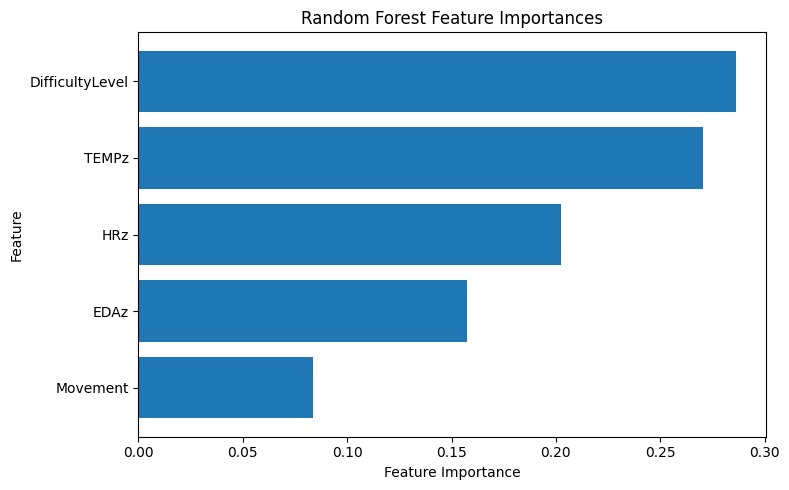

In [61]:
X = df[physio_features]
y = df[target]
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    random_state=42
)

rf.fit(X, y)
importances = rf.feature_importances_

import pandas as pd

importance_df = pd.DataFrame({
    "Feature": physio_features,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [62]:
physio_only_no_diff = [
    "EDAz",
    "TEMPz",
    "HRz",
    "Movement"
]
results_no_diff = run_lopo(physio_only_no_diff)
from sklearn.metrics import roc_auc_score

print(f"{'Model':<20} {'AUC':<10}")
print("-" * 30)

for model_name, data in results_no_diff.items():

    y_true = data["y_true"]
    y_prob = data["y_prob"]

    try:
        auc = roc_auc_score(y_true, y_prob)
        print(f"{model_name:<20} {auc:<10.4f}")

    except:
        print(f"{model_name:<20} {'N/A':<10}")


Model                AUC       
------------------------------
Majority Baseline    0.4309    
Logistic Regression  0.4359    
Decision Tree        0.5676    
KNN                  0.6147    
Random Forest        0.6321    
